# Estimating Winter Temperature Trends for Urbana’s Outdoor Market Transition

---
embed-resources: true
---

## Introduction

This lab focuses on predicting the minimum daily air temperature in Urbana, Illinois to help determine when the farmers market should move indoors for winter. Using historical weather data, we train a K-Nearest Neighbors (KNN) regression model to estimate temperature trends for 2025. The goal is to provide a data-driven recommendation to city officials for scheduling the transition, ensuring a comfortable environment for vendors and visitors.

## Methods

In [33]:
# imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error

### Data

In [34]:
# load data
weather_train = pd.read_parquet(
    "https://cs307.org/lab/data/weather-train.parquet",
)
weather_vtrain = pd.read_parquet(
    "https://cs307.org/lab/data/weather-vtrain.parquet",
)
weather_validation = pd.read_parquet(
    "https://cs307.org/lab/data/weather-validation.parquet",
)
weather_test = pd.read_parquet(
    "https://cs307.org/lab/data/weather-test.parquet",
)

 The data is split according by time, specifically based on years.

- Train: 2016 - 2022
- Validation-Train: 2016 - 2020
- Validation: 2021 - 2022
- Test: 2023
- Production: 2024

The index of each data frame is the full date using the ISO 8601 standard. For example, 2020-07-04.

#### Response
`temperature_2m_min`

- `[float64]` the minimum air temperature at 2 meters above ground for the day
#### Features
`year`

- `[int64]` year , such as 2020

`month`

- `[int64]` month , such as 10 for October

`day`

- `[int64]` day of the month, for example 20 for January 20

`day_of_year`

- `[int64]` day of the year, for example 100, which in non-leap years in is April 9
For this lab, we require the use of only the year and day_of_year features.

In [35]:
# summary statistics
weather_train[['temperature_2m_min','year']].groupby(by='year').agg(['mean', 'std'])

temperature_2m_min           
                   mean        std
year                              
2016           8.793390  10.274506
2017           8.399644   9.692305
2018           7.591013  11.369452
2019           7.229781  10.882259
2020           7.684612   9.383594
2021           8.119370  10.388490
2022           7.010192  11.028170

In [36]:
# summary statistics
weather_train[['temperature_2m_min','month']].groupby(by='month').agg(['mean', 'std'])

temperature_2m_min          
                    mean       std
month                             
1              -5.416767  6.547430
2              -4.380614  6.746121
3               1.522173  5.595675
4               5.925214  5.659612
5              12.639454  5.234890
6              18.211405  3.540279
7              19.998209  2.627939
8              19.088070  2.874603
9              16.571642  3.988397
10              9.756274  5.775242
11              1.888310  5.663248
12             -2.514693  5.680540

The temperature standard deviation is lower in summer (e.g., 2.63°C in July) and higher in winter (e.g., 6.75°C in February). This indicates that winter temperatures fluctuate more compared to the relatively stable summer months.

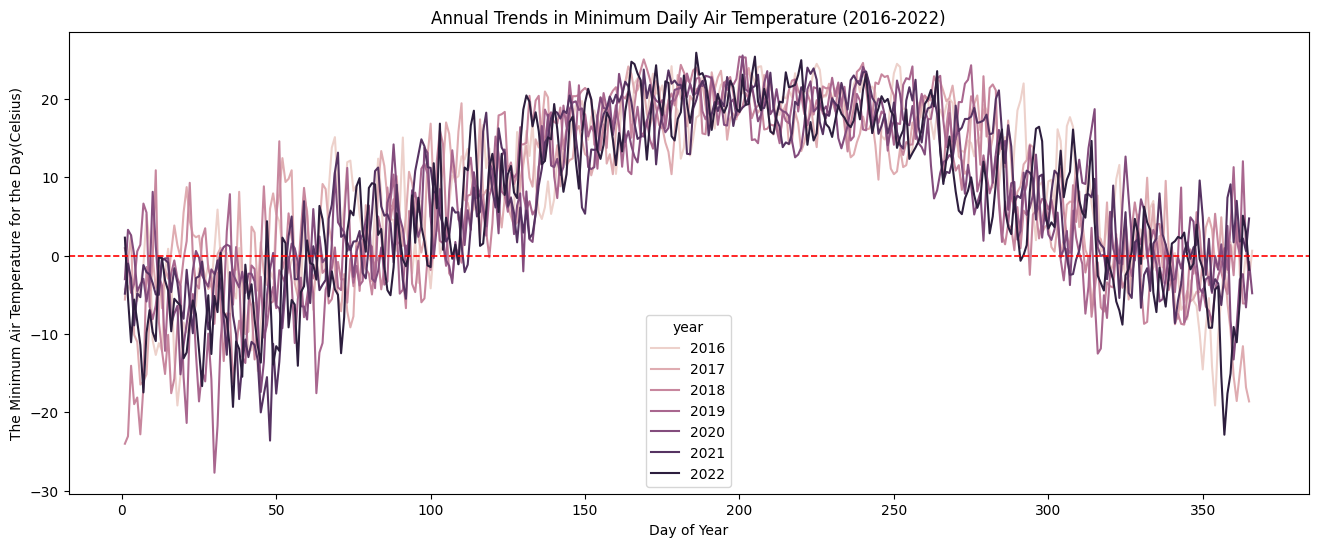

In [37]:
# exploratory visualization
plt.figure(figsize=(16, 6))
ax = sns.lineplot(data=weather_train, x="day_of_year", y="temperature_2m_min", hue="year")

# Adding labels and title
ax.set(
    xlabel="Day of Year",
    ylabel="The Minimum Air Temperature for the Day(Celsius)",
    title="Annual Trends in Minimum Daily Air Temperature (2016-2022)"
)
ax.axhline(y=0, color='red', linestyle='--', linewidth=1.2)  # Dashed black line

plt.show()

A key observation is the year-to-year variability in winter temperatures. While some years (e.g., 2021 and 2022) exhibit colder winter extremes, others (e.g., 2016-2018) show relatively milder conditions. This variability suggests that relying solely on average trends could be risky when making decisions about when to move market operations indoors. A more cautious approach would be to consider earlier transition dates to avoid unexpected freezing conditions.

### Models

In [38]:
# process data for ML
# create X and y for train
X_train = weather_train[["year", "day_of_year"]]
y_train = weather_train["temperature_2m_min"]

# create X and y for validation-train
X_vtrain = weather_vtrain[["year", "day_of_year"]]
y_vtrain = weather_vtrain["temperature_2m_min"]

# create X and y for validation
X_validation = weather_validation[["year", "day_of_year"]]
y_validation = weather_validation["temperature_2m_min"]

# create X and y for test
X_test = weather_test[["year", "day_of_year"]]
y_test = weather_test["temperature_2m_min"]

For this lab, It is required to use only the year and day_of_year features.

In [39]:
# train models
# try many values of k for knn
val_rmse_values = []
k_to_try = [1, 5, 10, 25, 50, 100, 250, 500]
for k in k_to_try:
    knn = KNeighborsRegressor(
        n_neighbors=k,
        p=1,  # manhattan distance via minkowski with p=1
    )
    knn.fit(X_vtrain, y_vtrain)
    pred = knn.predict(X_validation)
    val_rmse = root_mean_squared_error(y_validation, pred)
    val_rmse_values.append(val_rmse)

# get best validation k and rmse
knn_k_best = k_to_try[np.argmin(val_rmse_values)]
knn_val_rmse_best = min(val_rmse_values)

# refit to full train data
mod = KNeighborsRegressor(
    n_neighbors=knn_k_best,
    p=1,
)
print(knn_k_best)
mod.fit(X_train, y_train)

100


KNeighborsRegressor(n_neighbors=100, p=1)

We developed a K-Nearest Neighbors (KNN) regression model to predict the minimum daily air temperature. We experimented with different values of k (number of neighbors), selecting from the set {1, 5, 10, 25, 50, 100, 250, 500}. The model used the Manhattan distance metric (p=1 in the Minkowski formula) to compute nearest neighbors.

To determine the optimal number of neighbors, We trained the KNN model for each value of k, computed the Root Mean Squared Error (RMSE) on the validation set, and selected the value of k that minimized the RMSE.

After identifying the best parameter (k=100), we refit the model using the full training dataset to ensure it generalizes well to unseen data. The final KNN model was configured with 100 neighbors and Manhattan distance, based on the optimal RMSE results.

## Results

In [40]:
# report model metrics
# calculate test RMSE
pred = mod.predict(X_test)
knn_test_rmse = root_mean_squared_error(y_test, pred)
knn_test_rmse

4.728918075561523

The selected model achieves a RMSE of 4.728918075561523,which means that, on average, model’s predicted minimum daily air temperature deviates by about 4.73°C from the actual values in the dataset.

<function matplotlib.pyplot.show(close=None, block=None)>

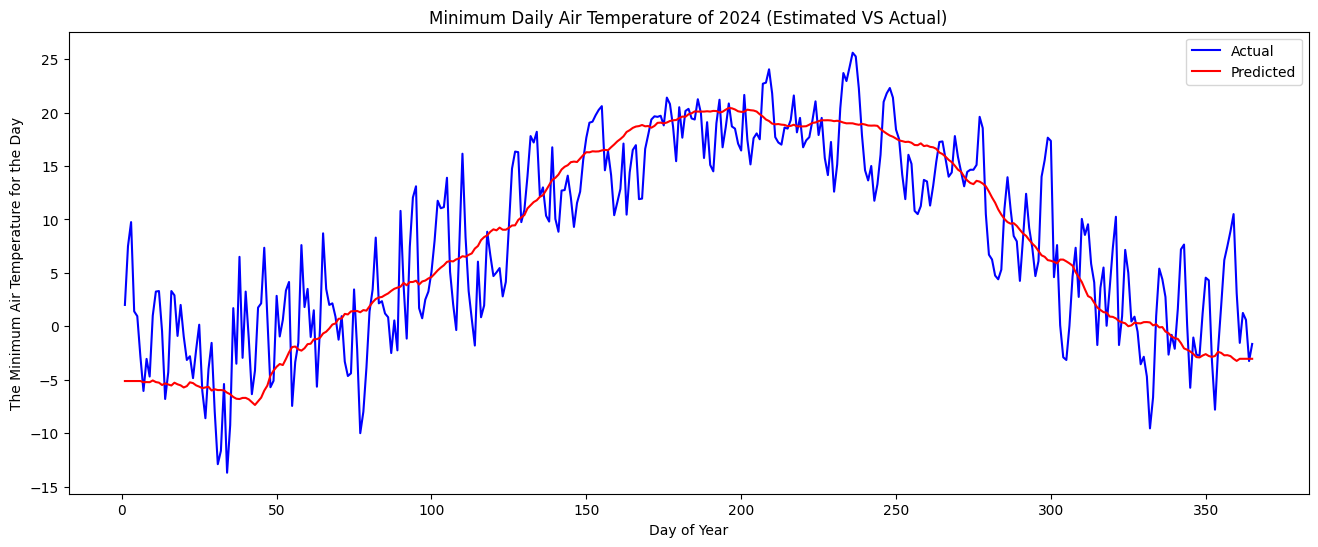

In [41]:
# summary figure
plt.figure(figsize=(16, 6))

df_2024=weather_test
df_2024['prediction']=mod.predict(X_test)

ax = sns.lineplot(data=df_2024, x='day_of_year', y='temperature_2m_min', label="Actual", color='blue')
sns.lineplot(data=df_2024, x='day_of_year', y='prediction', label="Predicted", color='red')

ax.set(
    xlabel="Day of Year",
    ylabel="The Minimum Air Temperature for the Day",
    title="Minimum Daily Air Temperature of 2024 (Estimated VS Actual)"
)
plt.show

The comparison plot between actual (blue) and predicted (red) temperatures for 2024 shows that while the model captures the overall seasonal trend, it smooths out short-term variations. The predicted values follow the general warming and cooling patterns but fail to capture the daily fluctuations and extreme temperature swings observed in the actual data. This is expected given that the model uses 100 neighbors, which results in a more generalized trend rather than precise day-to-day predictions.

In [42]:
# serialize model
from joblib import dump
dump(mod, "weather.joblib")

['weather.joblib']

## Discussion

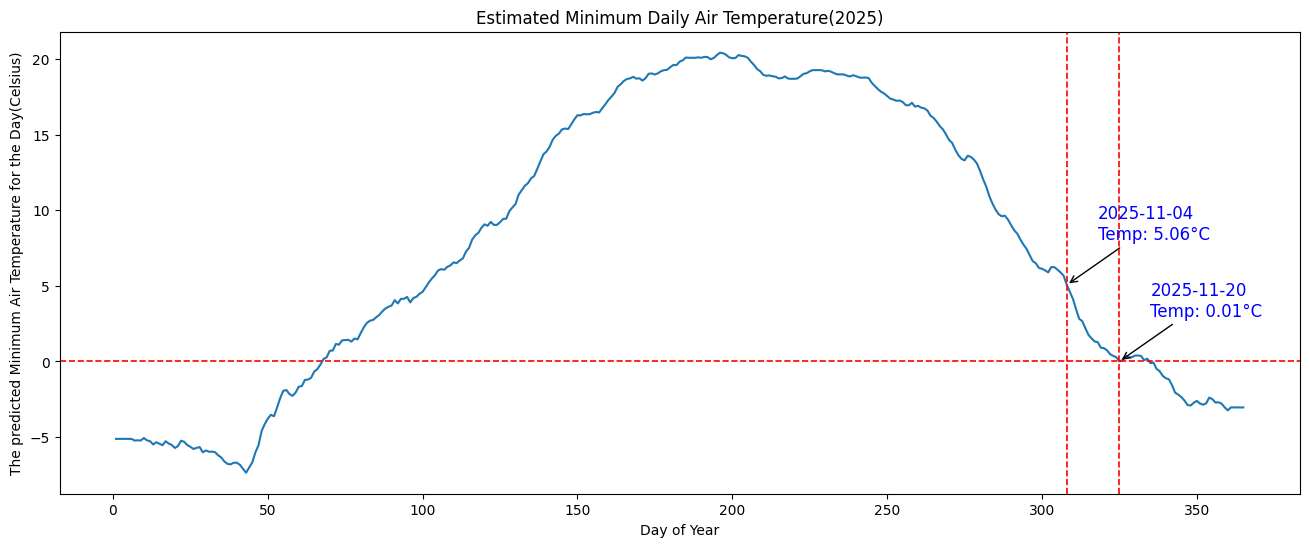

In [43]:
# creating data 
date_range = pd.date_range(start="2025-01-01", end="2025-12-31", freq='D')

# Create the dataset
df_2025 = pd.DataFrame({
    "date": date_range,
    "year": date_range.year,
    "day_of_year": date_range.dayofyear
})

# Set the index to be the date column
df_2025.set_index("date", inplace=True)

#get the exact date
close_to_five_days = df_2025[
    (np.abs(mod.predict(df_2025) - 5) < 0.1)
]
close_to_zero_days = df_2025[
    (np.abs(mod.predict(df_2025) - 0) < 0.1)
]


plt.figure(figsize=(16, 6))

ax = sns.lineplot(x=df_2025['day_of_year'], y=mod.predict(df_2025))

# Adding labels and title
ax.set(
    xlabel="Day of Year",
    ylabel="The predicted Minimum Air Temperature for the Day(Celsius)",
    title="Estimated Minimum Daily Air Temperature(2025)"
)
ax.axhline(y=0, color='red', linestyle='--', linewidth=1.2)
ax.axvline(x=308, color='red', linestyle='--', linewidth=1.2)

ax.annotate(f"2025-11-04\nTemp: {mod.predict(df_2025)[307]:.2f}°C",
            xy=(308, mod.predict(df_2025)[307]),
            xytext=(308 + 10, mod.predict(df_2025)[307] + 3),  # Offset for readability
            arrowprops=dict(facecolor='blue', arrowstyle='->'),
            fontsize=12, color='blue')

ax.axvline(x=325, color='red', linestyle='--', linewidth=1.2)

ax.annotate(f"2025-11-20\nTemp: {mod.predict(df_2025)[324]:.2f}°C",
            xy=(325, mod.predict(df_2025)[324]),
            xytext=(325 + 10, mod.predict(df_2025)[324] + 3),  # Offset for readability
            arrowprops=dict(facecolor='blue', arrowstyle='->'),
            fontsize=12, color='blue')

plt.show()

We consider a temperature below 0°C to be cold enough for the market to move indoors. Based on our plot, we identified two key dates:

- for 2025-11-20, This is the estimated date when the minimum air temperature is expected to reach 0°C.

- for 2025-11-04, This is the estimated date when the minimum air temperature is expected to reach 5°C.

We recommend moving the market indoors by November 20, 2025, as our model predicts that temperatures will drop below 0°C around this time. However, given that our model has an RMSE of 4.73°C, there is some uncertainty in the exact date. Therefore, a safer option would be to move indoors by November 4, 2025, to ensure comfortable conditions for vendors and visitors.

The K-Nearest Neighbors (KNN) model provides a general estimate for minimum daily air temperature, offering insights into seasonal trends. However, with an RMSE of 4.73°C, the model lacks precision, making it unreliable for critical decisions. Additionally, it does not account for sudden weather changes, such as cold fronts or extreme temperature shifts, which are important for planning.

Relying on this model could lead to incorrect timing for moving the market indoors if the predicted temperatures are inaccurate. People would get hurt and frozen if the moving date is not accurate. To improve accuracy, incorporating additional weather variables (e.g., wind speed, humidity) or using more advanced models could enhance predictions.

Given the model's limitations and potential prediction errors, I would not use it in practice as the primary decision-making tool. Instead, I would rely on real-time weather forecasts and historical patterns for a more informed decision. While the model provides general guidance, its uncertainty makes it insufficient for precise operational planning.